In [2]:
import pandas as pd
import numpy as np

In [3]:
X_train = pd.read_csv('/content/X_train.csv')
X_val   = pd.read_csv('/content/X_val.csv')
X_test  = pd.read_csv('/content/X_test.csv')

y_train = pd.read_csv('/content/y_train.csv').squeeze()
y_val   = pd.read_csv('/content/y_val.csv').squeeze()
y_test  = pd.read_csv('/content/y_test.csv').squeeze()

print(X_train.shape, X_val.shape, X_test.shape)

(16416, 45) (2052, 45) (2053, 45)


In [ ]:
X_train.dtypes

In [5]:
# filling remaining NaN in host_experience_level before encoding
X_train['host_experience_level'] = X_train['host_experience_level'].fillna('Experienced')
X_val['host_experience_level']   = X_val['host_experience_level'].fillna('Experienced')
X_test['host_experience_level']  = X_test['host_experience_level'].fillna('Experienced')

In [6]:
print(X_train['host_experience_level'].isnull().sum())

0


In [7]:
#doing encoding(i have refered to the book: hands on ml with pytorch by Aurelien geron)

#1. Changing bools to int
bool_cols = ['host_is_superhost', 'has_availability']
for col in bool_cols:
  X_train[col] = X_train[col].astype(int)
  X_val[col] = X_val[col].astype(int)
  X_test[col] = X_test[col].astype(int)

#2. for ordered categories like in host_exp level, we will use ordinalEncoder
from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(categories=[['New', 'Intermediate', 'Experienced']])
X_train['host_experience_level'] = ord_enc.fit_transform(X_train[['host_experience_level']])
X_val['host_experience_level']   = ord_enc.transform(X_val[['host_experience_level']])
X_test['host_experience_level']  = ord_enc.transform(X_test[['host_experience_level']])

#3. for columns with no natural order, we will use OneHotEncoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

one_cols = ['room_type', 'neighbourhood_group_cleansed', 'property_type']
one_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = pd.DataFrame(one_enc.fit_transform(X_train[one_cols]),
                         columns=one_enc.get_feature_names_out(one_cols),
                         index=X_train.index)

ohe_val = pd.DataFrame(one_enc.transform(X_val[one_cols]),
                       columns=one_enc.get_feature_names_out(one_cols),
                       index=X_val.index)

ohe_test = pd.DataFrame(one_enc.transform(X_test[one_cols]),
                        columns=one_enc.get_feature_names_out(one_cols),
                        index=X_test.index)

X_train = pd.concat([X_train.drop(columns=one_cols), ohe_train], axis=1)
X_val   = pd.concat([X_val.drop(columns=one_cols), ohe_val], axis=1)
X_test  = pd.concat([X_test.drop(columns=one_cols), ohe_test], axis=1)

#4. on page (97-98) in my book, it says in the tips section that applying OHE on large amout of input features will slow the system down
#   so its better to replace categorial features with numerical features.
#   and neighbourhood_cleansed has 200+ unique nighbourhoods, so OHE would create 200+ diff input features.
#   so i am going to replace that with mean log_price of that neighbourhood (from train set)

neigh_means = X_train.copy()
neigh_means['log_price'] = y_train.values
neigh_means = neigh_means.groupby('neighbourhood_cleansed')['log_price'].mean()

global_mean = y_train.mean()

X_train['neighbourhood_cleansed'] = X_train['neighbourhood_cleansed'].map(neigh_means).fillna(global_mean)
X_val['neighbourhood_cleansed'] = X_val['neighbourhood_cleansed'].map(neigh_means).fillna(global_mean)
X_test['neighbourhood_cleansed'] = X_test['neighbourhood_cleansed'].map(neigh_means).fillna(global_mean)

In [8]:
#scaling (Done after encoding)

from sklearn.preprocessing import RobustScaler

scale_cols = ['hosts_time_as_host_years', 'accommodates', 'bathrooms', 'bedrooms',
              'maximum_nights', 'maximum_nights_avg_ntm', 'number_of_reviews',
              'estimated_occupancy_l365d', 'days_since_first_review',
              'days_since_last_review', 'calculated_host_listings_count',
              'amenity_count', 'availability_rate', 'total_availability_score',
              'review_scores_cleanliness', 'review_scores_location',
              'review_score_avg', 'neighbourhood_cleansed']

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

Writing the models

In [9]:
#1. Ridge (baseline model)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

baseline = Ridge(alpha=1.0)
baseline.fit(X_train, y_train)

val_preds = baseline.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2 = r2_score(y_val, val_preds)

print(f"Ridge baseline - RMSE: {rmse:.4f}, R²: {r2:.4f}")

val_preds_dollars = np.expm1(val_preds)
y_val_dollars = np.expm1(y_val)
dollar_rmse = np.sqrt(mean_squared_error(y_val_dollars, val_preds_dollars))
print(f"Average prediction error: ${dollar_rmse:.2f}")

Ridge baseline - RMSE: 0.4830, R²: 0.6286
Average prediction error: $1169.75


In [10]:
#2. Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth = 15, min_samples_leaf = 5, random_state=42, n_jobs = -1)

rf.fit(X_train, y_train)

val_preds_rf = rf.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, val_preds_rf))
r2_rf = r2_score(y_val, val_preds_rf)

print(f"Random Forest - RMSE: {rmse_rf:.4f}, R²: {r2_rf:.4f}")

Random Forest - RMSE: 0.4193, R²: 0.7202


In [ ]:
#3. XGBoost (old xgboost)

# from xgboost import XGBRegressor

# xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

# xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose = 50)

# val_preds_xgb = xgb.predict(X_val)
# rmse_xgb = np.sqrt(mean_squared_error(y_val, val_preds_xgb))
# r2_xgb = r2_score(y_val, val_preds_xgb)
# print(f"XGBoost - RMSE: {rmse_xgb:.4f}, R²: {r2_xgb:.4f}")

[0]	validation_0-rmse:0.76941
[50]	validation_0-rmse:0.43979
[100]	validation_0-rmse:0.41379
[150]	validation_0-rmse:0.40392
[200]	validation_0-rmse:0.39859
[250]	validation_0-rmse:0.39432
[300]	validation_0-rmse:0.39048
[350]	validation_0-rmse:0.38943
[400]	validation_0-rmse:0.38803
[450]	validation_0-rmse:0.38641
[499]	validation_0-rmse:0.38497
XGBoost - RMSE: 0.3850, R²: 0.7641


In [11]:
# 3. new xgboost (with early stopping)
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

xgb_es = XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, eval_metric='rmse', early_stopping_rounds=50)

xgb_es.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose = 50)

best_n = xgb_es.best_iteration
print(f"\nBest n_estimators: {best_n}")
print(f"Best val RMSE: {xgb_es.best_score:.4f}")

val_preds_es = xgb_es.predict(X_val)
print(f"Val R2: {r2_score(y_val, val_preds_es):.4f}")

[0]	validation_0-rmse:0.76941
[50]	validation_0-rmse:0.43979
[100]	validation_0-rmse:0.41379
[150]	validation_0-rmse:0.40392
[200]	validation_0-rmse:0.39859
[250]	validation_0-rmse:0.39432
[300]	validation_0-rmse:0.39048
[350]	validation_0-rmse:0.38943
[400]	validation_0-rmse:0.38803
[450]	validation_0-rmse:0.38641
[500]	validation_0-rmse:0.38493
[550]	validation_0-rmse:0.38407
[600]	validation_0-rmse:0.38364
[650]	validation_0-rmse:0.38368
[677]	validation_0-rmse:0.38349

Best n_estimators: 627
Best val RMSE: 0.3831
Val R2: 0.7664


In [12]:
#RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'n_estimators': [100, 200, 300, 400, 500],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 1.5, 2],
}

xgb_random = XGBRegressor(n_estimators=627, random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    xgb_random,
    param_distributions=param_dist,
    n_iter=50,
    scoring='r2',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"\nBest params found:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest CV R²:  {random_search.best_score_:.4f}")

val_preds_random = random_search.best_estimator_.predict(X_val)
print(f"Val R²:      {r2_score(y_val, val_preds_random):.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best params found:
  subsample: 0.9
  reg_lambda: 1
  reg_alpha: 0.01
  n_estimators: 500
  min_child_weight: 3
  max_depth: 8
  learning_rate: 0.03
  gamma: 0
  colsample_bytree: 0.8

Best CV R²:  0.7540
Val R²:      0.7657


In [14]:
import time

start = time.time()

XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=3,
    tree_method="hist",
    random_state=42
).fit(X_train, y_train)

print(time.time() - start)

10.553953170776367


In [15]:
# GridSearchCV (refined search around RandomizedSearchCV best params)

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

param_grid = {
    'max_depth': [7, 8, 9],
    'learning_rate': [0.02, 0.03, 0.04],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'min_child_weight': [1, 3]
}

total_combinations = (len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample']) * len(param_grid['colsample_bytree']) * len(param_grid['min_child_weight']))

print(f"Total combinations: {total_combinations}")
print(f"Total fits (cv=3): {total_combinations * 3}")

xgb_grid = XGBRegressor(
    n_estimators=500,
    gamma=0,
    reg_alpha=0.01,
    reg_lambda=1,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest params after GridSearchCV:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

val_preds = best_model.predict(X_val)

print(f"Val R²: {r2_score(y_val, val_preds):.4f}")

Total combinations: 72
Total fits (cv=3): 216
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best params after GridSearchCV:
  colsample_bytree: 0.8
  learning_rate: 0.04
  max_depth: 8
  min_child_weight: 1
  subsample: 0.8

Best CV R²: 0.7555
Val R²: 0.7689


In [16]:
#Final model
xgb_best = XGBRegressor(
    # best params from GridSearchCV
    max_depth=8,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.01,
    reg_lambda=1,
    tree_method='hist',
    n_estimators=3000,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1
)

xgb_best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f"\nBest n_estimators: {xgb_best.best_iteration}")

val_preds_best = xgb_best.predict(X_val)
val_r2_best = r2_score(y_val, val_preds_best)
print(f"Val R²:            {val_r2_best:.4f}")

[0]	validation_0-rmse:0.77259
[100]	validation_0-rmse:0.40596
[200]	validation_0-rmse:0.39092
[300]	validation_0-rmse:0.38575
[400]	validation_0-rmse:0.38297
[500]	validation_0-rmse:0.38099
[600]	validation_0-rmse:0.38039
[700]	validation_0-rmse:0.37941
[772]	validation_0-rmse:0.37940

Best n_estimators: 722
Val R²:            0.7711


In [17]:
test_preds_best  = xgb_best.predict(X_test)
test_r2_best     = r2_score(y_test, test_preds_best)
test_dollar_best = np.sqrt(mean_squared_error(
                       np.expm1(y_test),
                       np.expm1(test_preds_best)))

print(f"\n======= FINAL TUNED MODEL =======")
print(f"Val R²:       {val_r2_best:.4f}")
print(f"Test R²:      {test_r2_best:.4f}")
print(f"Dollar error: ${test_dollar_best:.2f}")


======= FINAL TUNED MODEL =======
Val R²:       0.7711
Test R²:      0.7680
Dollar error: $188.06


In [18]:
import joblib
joblib.dump(xgb_best, 'xgboost_tuned_final.pkl')

['xgboost_tuned_final.pkl']

In [19]:
from google.colab import files
files.download('xgboost_tuned_final.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
#comparing models and picking the best
# Final comparison — all models
results_final = pd.DataFrame({
    'Model':      ['Ridge Baseline', 'Random Forest', 'XGBoost (default)', 'XGBoost (tuned)'],
    'Val R²':     [0.6286,           0.7202,           0.7641,              val_r2_best],
    'Dollar Error':['$1169',         '$247',            '$224',             f'${test_dollar_best:.2f}'],
})
print(results_final.sort_values('Val R²', ascending=False).to_string(index=False))


            Model   Val R² Dollar Error
  XGBoost (tuned) 0.771074      $188.06
XGBoost (default) 0.764100         $224
    Random Forest 0.720200         $247
   Ridge Baseline 0.628600        $1169


In [22]:
print(X_train.shape)
print(X_train.dtypes.value_counts())
print(X_train.isnull().sum().sum())

(16416, 99)
float64    83
int64      16
Name: count, dtype: int64
0


In [24]:
# # dollar error for all three models - replaced by tuned model evaluation above
# for name, preds in [('Ridge', val_preds), ('Random Forest', val_preds_rf), ('XGBoost', val_preds_xgb)]:
#     dollar_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds)))
#     print(f"{name}: ${dollar_rmse:.2f} average error")

# updated dollar errors (hardcoded from previous runs)
for name, error in [('Ridge', 1169.75), ('Random Forest', 246.94), ('XGBoost (default)', 223.95), ('XGBoost (tuned)', test_dollar_best)]:
    print(f"{name}: ${error:.2f} average error")

Ridge: $1169.75 average error
Random Forest: $246.94 average error
XGBoost (default): $223.95 average error
XGBoost (tuned): $188.06 average error


In [26]:
# Old test evaluation — commented out, replaced by tuned model results above
# test_preds = xgb.predict(X_test)
# test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
# test_r2 = r2_score(y_test, test_preds)
# print(f"FINAL TEST — RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")
# test_dollar_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_preds)))
# print(f"Average prediction error: ${test_dollar_rmse:.2f}")

# Final results from tuned model:
print(f"FINAL TEST — R²: {test_r2_best:.4f}, Error: ${test_dollar_best:.2f}")

FINAL TEST — R²: 0.7680, Error: $188.06


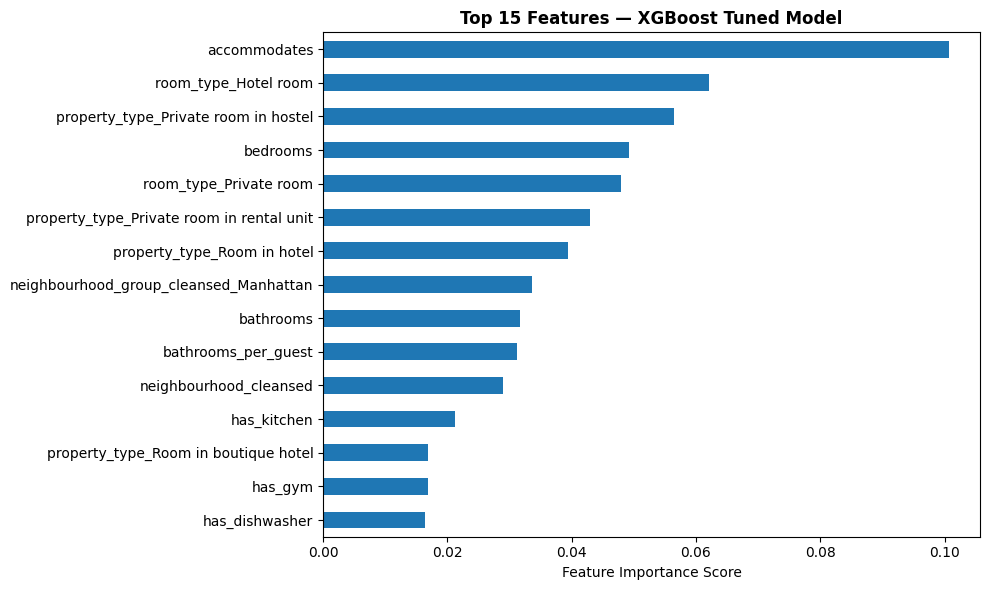

In [27]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb_best.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Features — XGBoost Tuned Model', fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

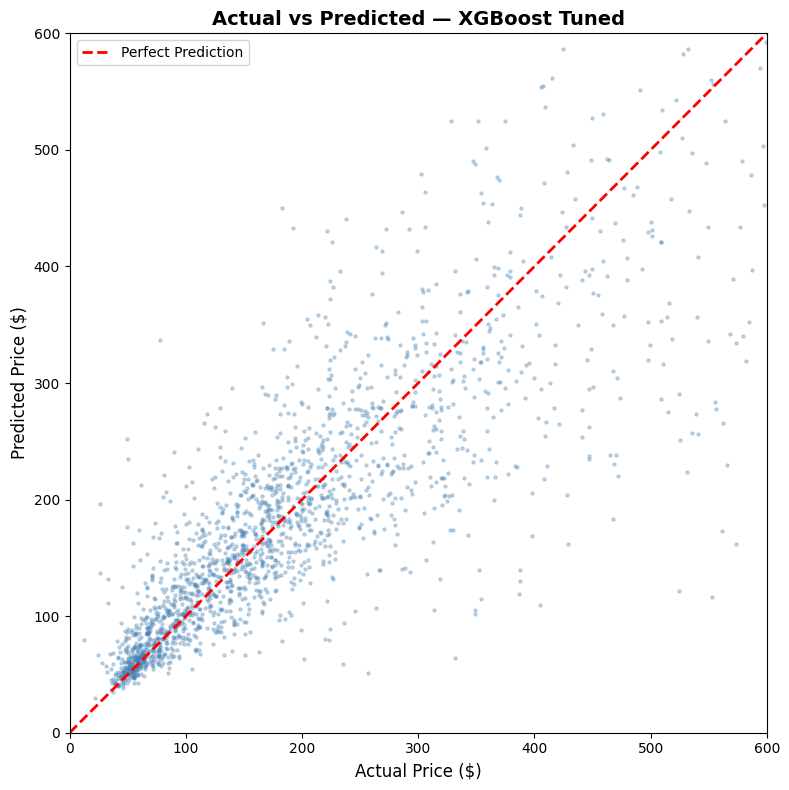


Final summary:
  Val R²:       0.7711
  Test R²:      0.7680
  Dollar error: $188.06


In [28]:
# Plot 6: Actual vs Predicted
import matplotlib.pyplot as plt
import numpy as np

actual_dollars = np.expm1(y_test)
pred_dollars   = np.expm1(test_preds_best)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(actual_dollars, pred_dollars, alpha=0.3, s=5, color='steelblue')
ax.plot([0, 600], [0, 600], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price ($)', fontsize=12)
ax.set_ylabel('Predicted Price ($)', fontsize=12)
ax.set_title('Actual vs Predicted — XGBoost Tuned', fontsize=14, fontweight='bold')
ax.set_xlim(0, 600)
ax.set_ylim(0, 600)
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal summary:")
print(f"  Val R²:       {val_r2_best:.4f}")
print(f"  Test R²:      {test_r2_best:.4f}")
print(f"  Dollar error: ${test_dollar_best:.2f}")